In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================================
# Urban Green Cover Image Assessment
# CNN + Transfer Learning using EuroSAT Dataset
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# 1. Paths
# ============================================================

# For Google Colab after uploading/unzipping:
# DATA_DIR = Path("/content/archive-3/EuroSAT")

# For Kaggle:
# DATA_DIR = Path("/kaggle/input/eurosat-dataset/EuroSAT")

# For local Mac/VS Code example:
# DATA_DIR = Path("/Users/happy/Downloads/archive-3/EuroSAT")

DATA_DIR = Path("/content/archive-3/EuroSAT")

OUTPUT_DIR = Path("outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_DIR.exists())

# ============================================================
# 2. Collect image paths and labels
# ============================================================

image_paths = []
labels = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(str(img_path))
                labels.append(class_dir.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.head())
print("Total images:", len(df))
print("Classes:", df["label"].nunique())
print(df["label"].value_counts())

# ============================================================
# 3. Visualize class distribution
# ============================================================

plt.figure(figsize=(10, 5))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png")
plt.show()

# ============================================================
# 4. Train / Validation / Test Split
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ============================================================
# 5. Parameters
# ============================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

class_names = sorted(df["label"].unique())
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

# ============================================================
# 6. Create TensorFlow Datasets
# ============================================================

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

label_lookup = {name: index for index, name in enumerate(class_names)}

train_labels = train_df["label"].map(label_lookup).values
val_labels = val_df["label"].map(label_lookup).values
test_labels = test_df["label"].map(label_lookup).values

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_labels)
)
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_labels)
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_labels)
)

train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ============================================================
# 7. Data Augmentation
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ============================================================
# 8. Custom CNN Model
# ============================================================

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# ============================================================
# 9. Train Custom CNN
# ============================================================

EPOCHS = 10

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ============================================================
# 10. Plot Accuracy and Loss Curves
# ============================================================

def plot_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_accuracy.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_loss.png")
    plt.show()

plot_history(cnn_history, "custom_cnn")

# ============================================================
# 11. Evaluate Custom CNN
# ============================================================

cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)
print("Custom CNN Test Accuracy:", cnn_acc)

y_true = []
y_pred = []

for images, labels_batch in test_ds:
    preds = cnn_model.predict(images)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "custom_cnn_confusion_matrix.png")
plt.show()

# ============================================================
# 12. Transfer Learning: MobileNetV2
# ============================================================

base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    keras.applications.mobilenet_v2.preprocess_input,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

# ============================================================
# 13. Train Transfer Learning Model
# ============================================================

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

plot_history(transfer_history, "mobilenetv2")

# ============================================================
# 14. Evaluate Transfer Learning Model
# ============================================================

transfer_loss, transfer_acc = transfer_model.evaluate(test_ds)
print("MobileNetV2 Test Accuracy:", transfer_acc)

y_true_t = []
y_pred_t = []

for images, labels_batch in test_ds:
    preds = transfer_model.predict(images)
    y_true_t.extend(labels_batch.numpy())
    y_pred_t.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_t, y_pred_t, target_names=class_names))

cm_t = confusion_matrix(y_true_t, y_pred_t)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("MobileNetV2 Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mobilenetv2_confusion_matrix.png")
plt.show()

# ============================================================
# 15. Model Comparison Table
# ============================================================

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2 Transfer Learning"],
    "Test Accuracy": [cnn_acc, transfer_acc],
    "Test Loss": [cnn_loss, transfer_loss]
})

print(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png")
plt.show()

# ============================================================
# 16. Save Models
# ============================================================

cnn_model.save("custom_cnn_model.keras")
transfer_model.save("mobilenetv2_model.keras")

print("All figures saved in:", OUTPUT_DIR)
print("Models saved successfully.")

2026-06-07 16:20:57.727573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780849258.022341      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780849258.109168      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780849258.737180      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780849258.737245      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780849258.737250      58 computation_placer.cc:177] computation placer alr

Dataset exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/content/archive-3/EuroSAT'

In [4]:
!ls /kaggle/input

In [6]:
!find /kaggle/input -type d | grep EuroSAT

In [7]:
import os

print("Current directory:", os.getcwd())

if os.path.exists('/kaggle/input'):
    print("Running on Kaggle")
else:
    print("Not running on Kaggle")

Current directory: /kaggle/working
Running on Kaggle


In [8]:
!ls /kaggle/input!find /kaggle/input -type d | head -50

datasets


In [9]:
!find /kaggle/input -type d | head -50

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanholbrook
/kaggle/input/datasets/ryanholbrook/eurosat
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0


In [10]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0")

print(DATA_DIR.exists())

True


In [18]:
image_paths = []
labels = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(str(img_path))
                labels.append(class_dir.name)

print("Images found:", len(image_paths))
print("Classes found:", len(set(labels)))

Images found: 0
Classes found: 0


In [19]:
!find /kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0 -type f | head -20


/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0/image.image.json
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0/dataset_info.json
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0/label.labels.txt
/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0/eurosat-train.tfrecord-00000-of-00001


In [20]:
!find /kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0 -type d | head -50

/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0


In [22]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0")

print("Exists:", DATA_DIR.exists())

for item in DATA_DIR.iterdir():
    print(item)

Exists: False


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0'

In [23]:
!ls /kaggle/input

datasets


In [24]:
!find /kaggle/input -maxdepth 5 -type d

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanholbrook
/kaggle/input/datasets/apollo2506
/kaggle/input/datasets/apollo2506/eurosat-dataset
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/SeaLake
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/Highway
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/River
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/Pasture
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/Industrial
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/Residential
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/PermanentCrop
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/AnnualCrop
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/Forest
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/HerbaceousVegetation
/kaggle/inp

In [25]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/ryanholbrook/eurosat/eurosat/rgb/2.0.0")

print("Exists:", DATA_DIR.exists())

if DATA_DIR.exists():
    for item in DATA_DIR.iterdir():
        print(item)
else:
    print("Dataset path not found. Run !ls /kaggle/input to find the correct path.")

Exists: False
Dataset path not found. Run !ls /kaggle/input to find the correct path.


In [26]:
!ls /kaggle/input

datasets


In [27]:
!find /kaggle/input -maxdepth 4 -type d

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/ryanholbrook
/kaggle/input/datasets/apollo2506
/kaggle/input/datasets/apollo2506/eurosat-dataset
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT


In [28]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT")

print(DATA_DIR.exists())for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        print(folder.name)

True


In [29]:
for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        print(folder.name)

SeaLake
Highway
River
Pasture
Industrial
Residential
PermanentCrop
AnnualCrop
Forest
HerbaceousVegetation


In [30]:
image_paths = []
labels = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(str(img_path))
                labels.append(class_dir.name)

print("Images found:", len(image_paths))
print("Classes found:", len(set(labels)))

Images found: 27000
Classes found: 10


In [31]:
df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(df.shape)
df.head()

(27000, 2)


,image_path,label
0,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
1,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
2,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
3,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop
4,/kaggle/input/datasets/apollo2506/eurosat-data...,AnnualCrop


Dataset exists: True
Total images: 27000
Classes: 10
label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
PermanentCrop           2500
Industrial              2500
River                   2500
Pasture                 2000
Name: count, dtype: int64
Train: 18900
Validation: 4050
Test: 4050


2026-06-07 17:43:20.513843: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,602 (24.87 MB)

 Trainable params: 6,518,602 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 333s 555ms/step - accuracy: 0.4985 - loss: 1.3674 - val_accuracy: 0.6911 - val_loss: 0.8819
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 325s 548ms/step - accuracy: 0.6641 - loss: 0.9498 - val_accuracy: 0.7457 - val_loss: 0.7003
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 325s 550ms/step - accuracy: 0.7077 - loss: 0.8228 - val_accuracy: 0.7674 - val_loss: 0.6526
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 387s 558ms/step - accuracy: 0.7343 - loss: 0.7436 - val_accuracy: 0.7872 - val_loss: 0.6143
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 330s 557ms/step - accuracy: 0.7549 - loss: 0.6888 - val_accuracy: 0.7281 - val_loss: 0.7966
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 328s 554ms/step - accuracy: 0.7752 - loss: 0.6444 - val_accuracy: 0.8341 - val_loss: 0.4753
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 331s 559ms/step - accuracy: 0.7892 - loss: 0.6085 - val_accuracy: 0.8388 - val_loss: 0.4680
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 329s 557ms/step - accuracy: 0.8075 -

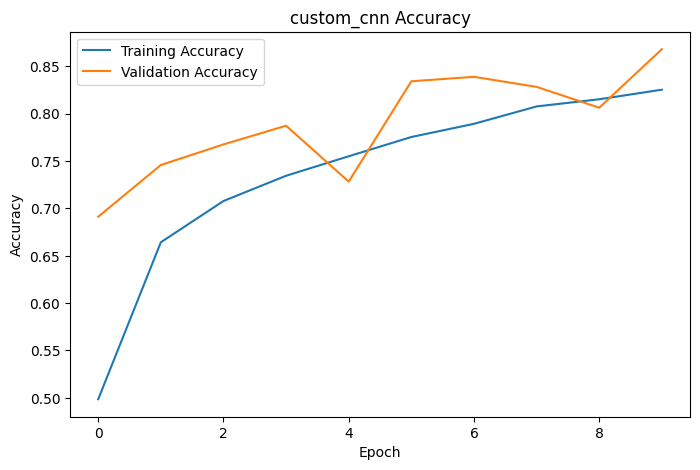

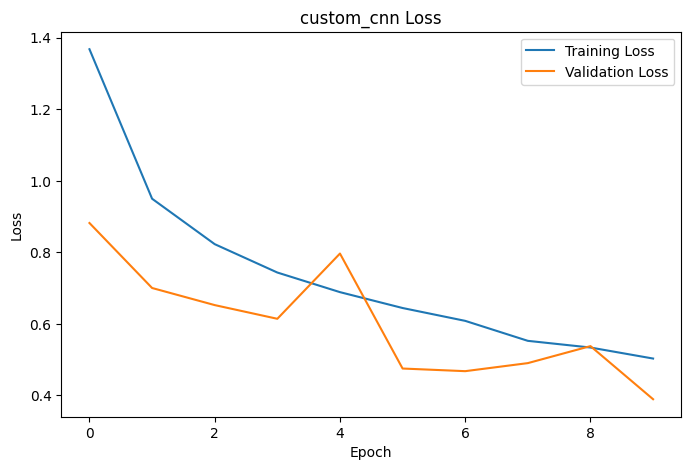

127/127 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.8627 - loss: 0.4090
Custom CNN Test Accuracy: 0.8627160787582397
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━

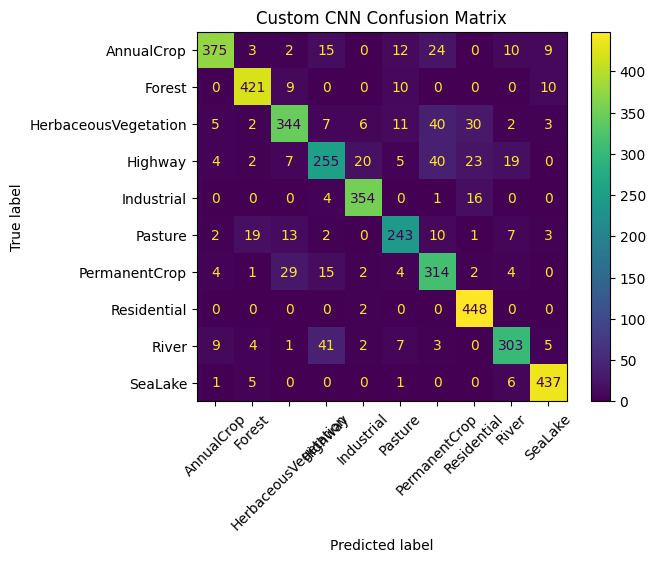

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <function preprocess_input at 0x7d3314df94e0> (of type <class 'function'>)

In [32]:
# =====================================================
# Urban Green Cover Image Assessment - Full Code
# =====================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# =====================================================
# 1. Correct Kaggle Dataset Path
# =====================================================

DATA_DIR = Path("/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSAT")
OUTPUT_DIR = Path("outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_DIR.exists())

# =====================================================
# 2. Collect Image Paths and Labels
# =====================================================

image_paths = []
labels = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                image_paths.append(str(img_path))
                labels.append(class_dir.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total images:", len(df))
print("Classes:", df["label"].nunique())
print(df["label"].value_counts())

# =====================================================
# 3. Train / Validation / Test Split
# =====================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# =====================================================
# 4. Parameters
# =====================================================

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

class_names = sorted(df["label"].unique())
num_classes = len(class_names)

label_lookup = {name: index for index, name in enumerate(class_names)}

train_labels = train_df["label"].map(label_lookup).values
val_labels = val_df["label"].map(label_lookup).values
test_labels = test_df["label"].map(label_lookup).values

# =====================================================
# 5. TensorFlow Dataset Loading
# =====================================================

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].values, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].values, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].values, test_labels)
)

train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# =====================================================
# 6. Data Augmentation
# =====================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# =====================================================
# 7. Custom CNN Model
# =====================================================

cnn_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

# =====================================================
# 8. Train Custom CNN
# =====================================================

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# =====================================================
# 9. Accuracy and Loss Curves
# =====================================================

def plot_history(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(model_name + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"{model_name}_accuracy.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(model_name + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"{model_name}_loss.png")
    plt.show()

plot_history(cnn_history, "custom_cnn")

# =====================================================
# 10. Evaluate Custom CNN
# =====================================================

cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)
print("Custom CNN Test Accuracy:", cnn_acc)

y_true = []
y_pred = []

for images, labels_batch in test_ds:
    preds = cnn_model.predict(images)
    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Custom CNN Confusion Matrix")
plt.savefig(OUTPUT_DIR / "custom_cnn_confusion_matrix.png")
plt.show()

# =====================================================
# 11. Transfer Learning - MobileNetV2
# =====================================================

base_model = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

transfer_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    keras.applications.mobilenet_v2.preprocess_input,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

plot_history(transfer_history, "mobilenetv2")

# =====================================================
# 12. Evaluate MobileNetV2
# =====================================================

transfer_loss, transfer_acc = transfer_model.evaluate(test_ds)
print("MobileNetV2 Test Accuracy:", transfer_acc)

y_true_t = []
y_pred_t = []

for images, labels_batch in test_ds:
    preds = transfer_model.predict(images)
    y_true_t.extend(labels_batch.numpy())
    y_pred_t.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_t, y_pred_t, target_names=class_names))

cm_t = confusion_matrix(y_true_t, y_pred_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("MobileNetV2 Confusion Matrix")
plt.savefig(OUTPUT_DIR / "mobilenetv2_confusion_matrix.png")
plt.show()

# =====================================================
# 13. Model Comparison
# =====================================================

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2 Transfer Learning"],
    "Test Accuracy": [cnn_acc, transfer_acc],
    "Test Loss": [cnn_loss, transfer_loss]
})

print(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.savefig(OUTPUT_DIR / "model_comparison.png")
plt.show()

# =====================================================
# 14. Save Models
# =====================================================

cnn_model.save("custom_cnn_model.keras")
transfer_model.save("mobilenetv2_model.keras")

print("Project completed successfully.")
print("Figures saved in:", OUTPUT_DIR)